In [1]:
import pandas as pd
df=pd.read_csv('nykaa_campaign_data_with_nulls.csv')
df

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,NaN,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,NaN,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,NY-CMP-56550,SEO,Youth,16.0,"Instagram, Email",31041.0,3849.0,1012.0,639.0,162945.0,374.90,-0.32,Tamil,17.72,Tier 2 City Customers,16-02-2025
55551,NY-CMP-56551,Paid Ads,Tier 2 City Customers,26.0,Facebook,27335.0,3715.0,2184.0,1006.0,792728.0,56.38,12.98,English,25.26,Premium Shoppers,18-11-2024
55552,NY-CMP-56552,Influencer,Tier 2 City Customers,23.0,NaN,43481.0,6447.0,3751.0,1668.0,383640.0,56.18,3.09,Bengali,27.29,Working Women,24-10-2024
55553,NY-CMP-56553,Social Media,College Students,16.0,"Facebook, Email",NaN,2518.0,584.0,299.0,194051.0,227.53,1.85,Bengali,10.14,Working Women,22-05-2025


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  str    
 1   Campaign_Type     52696 non-null  str    
 2   Target_Audience   52794 non-null  str    
 3   Duration          52665 non-null  float64
 4   Channel_Used      52750 non-null  str    
 5   Impressions       52775 non-null  float64
 6   Clicks            52773 non-null  float64
 7   Leads             52776 non-null  float64
 8   Conversions       52889 non-null  float64
 9   Revenue           52743 non-null  float64
 10  Acquisition_Cost  52742 non-null  float64
 11  ROI               52730 non-null  float64
 12  Language          52787 non-null  str    
 13  Engagement_Score  52806 non-null  float64
 14  Customer_Segment  52767 non-null  str    
 15  Date              52797 non-null  str    
dtypes: float64(9), str(7)
memory usage: 10.9 MB


In [3]:
df.isnull().sum()

Campaign_ID            0
Campaign_Type       2859
Target_Audience     2761
Duration            2890
Channel_Used        2805
Impressions         2780
Clicks              2782
Leads               2779
Conversions         2666
Revenue             2812
Acquisition_Cost    2813
ROI                 2825
Language            2768
Engagement_Score    2749
Customer_Segment    2788
Date                2758
dtype: int64

In [4]:
df=df.drop_duplicates()

In [5]:
#1 EDA
df.shape

(55555, 16)

In [6]:
null_info = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
})

print(null_info[null_info['null_count'] > 0])

                  null_count  null_%    dtype
Campaign_Type           2859    5.15      str
Target_Audience         2761    4.97      str
Duration                2890    5.20  float64
Channel_Used            2805    5.05      str
Impressions             2780    5.00  float64
Clicks                  2782    5.01  float64
Leads                   2779    5.00  float64
Conversions             2666    4.80  float64
Revenue                 2812    5.06  float64
Acquisition_Cost        2813    5.06  float64
ROI                     2825    5.09  float64
Language                2768    4.98      str
Engagement_Score        2749    4.95  float64
Customer_Segment        2788    5.02      str
Date                    2758    4.96      str


In [7]:
cat_cols = ['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language', 'Customer_Segment']

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [8]:
#2
print(df['Revenue'].describe())
print(df['Engagement_Score'].describe())

count    5.274300e+04
mean     5.156704e+05
std      4.900234e+05
min      6.183000e+03
25%      1.773790e+05
50%      3.598320e+05
75%      6.881200e+05
max      4.579910e+06
Name: Revenue, dtype: float64
count    52806.000000
mean        13.781463
std          6.351002
min          2.600000
25%          8.360000
50%         13.610000
75%         18.850000
max         30.910000
Name: Engagement_Score, dtype: float64


In [9]:
df['Engagement_Score']=df['Engagement_Score'].fillna(df['Engagement_Score'].mean())
df['Revenue']=df['Revenue'].fillna(df['Revenue'].median())

In [10]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 142


0           6.14
1           3.26
2        2175.00
3           0.60
4           0.80
          ...   
55550      -0.32
55551      12.98
55552       3.09
55553       1.85
55554       8.74
Name: ROI, Length: 55555, dtype: float64

In [11]:
df['Impressions'] = df.groupby('Channel_Used')['Impressions'] \
                      .transform(lambda x: x.fillna(x.median()))
df['Clicks'] = df.groupby('Channel_Used')['Clicks'] \
                 .transform(lambda x: x.fillna(x.median()))

In [12]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.impute import KNNImputer

numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score']

imputer = KNNImputer(n_neighbors=5)

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [14]:
mask = df['ROI'].isnull() & df['Revenue'].notnull() & df['Acquisition_Cost'].notnull()
df.loc[mask, 'ROI'] = df.loc[mask, 'Revenue'] / df.loc[mask, 'Acquisition_Cost']
print("ROI nulls remaining:", df['ROI'].isnull().sum())
df['ROI'].fillna(df['ROI'].median())

ROI nulls remaining: 0


0           6.14
1           3.26
2        2175.00
3           0.60
4           0.80
          ...   
55550      -0.32
55551      12.98
55552       3.09
55553       1.85
55554       8.74
Name: ROI, Length: 55555, dtype: float64

In [15]:
df=df.drop('Date',axis=1)

In [16]:
#3
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.447668,55122.507092,4651.658915,1877.510320,1032.342479,5.077824e+05,377.874581,306.935369,13.781463
std,7.357456,25262.217669,3103.106554,1429.337923,858.883990,4.786811e+05,538.659311,3362.215255,6.191874
min,5.000000,10001.000000,202.000000,56.000000,20.000000,6.183000e+03,9.430000,-0.970000,2.600000
25%,11.000000,33931.000000,2192.000000,781.000000,401.000000,1.857300e+05,106.565000,0.090000,8.650000
50%,17.000000,55148.000000,3926.000000,1484.000000,780.000000,3.598320e+05,208.700000,1.410000,13.781463
75%,24.000000,76381.000000,6515.000000,2608.000000,1414.400000,6.603590e+05,429.560000,4.320000,18.580000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,307715.894040,30.910000


In [17]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


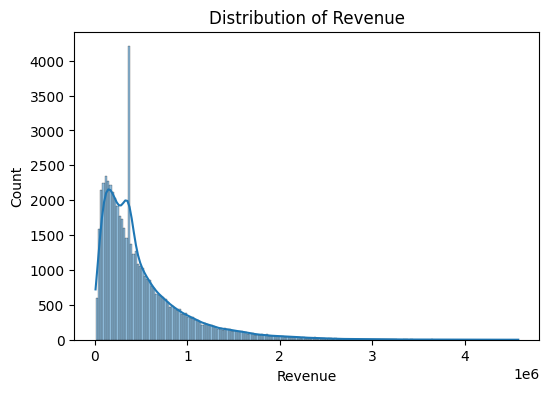

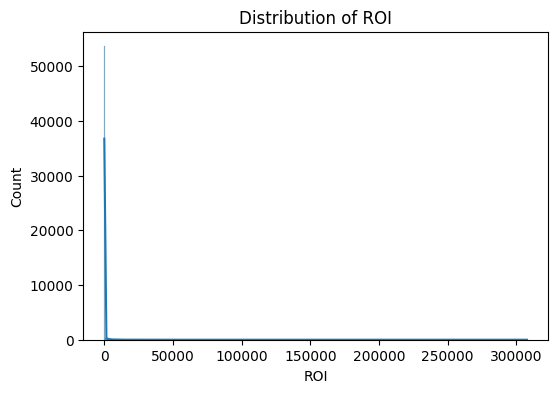

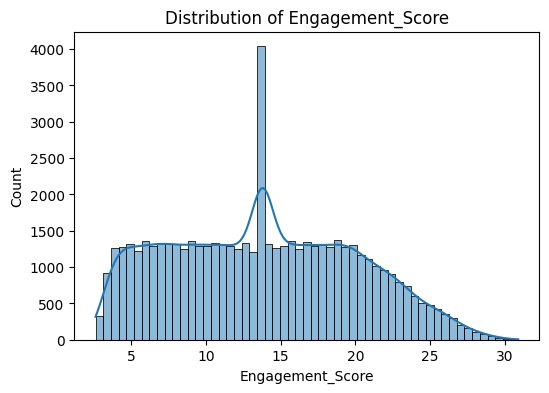

In [18]:
# 4. Univariate distribution - numeric columns
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['Revenue', 'ROI', 'Engagement_Score']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [19]:
# 5. Value counts for categorical columns
for col in ['Campaign_Type', 'Channel_Used', 'Customer_Segment', 'Target_Audience', 'Language']:
    print(df[col].value_counts())
    print()

Campaign_Type
Paid Ads        10570
Influencer      10553
Social Media    10535
Email           10520
SEO             10518
Unknown          2859
Name: count, dtype: int64

Channel_Used
Instagram                       3045
YouTube                         2974
WhatsApp                        2950
Google                          2925
Email                           2906
                                ... 
WhatsApp, Google, Instagram      123
Google, Facebook, Instagram      121
YouTube, WhatsApp, Instagram     120
WhatsApp, YouTube, Email         117
Email, YouTube, Facebook         104
Name: count, Length: 157, dtype: int64

Customer_Segment
College Students         10766
Working Women            10557
Youth                    10525
Premium Shoppers         10500
Tier 2 City Customers    10419
Unknown                   2788
Name: count, dtype: int64

Target_Audience
Working Women            10677
Premium Shoppers         10643
College Students         10532
Tier 2 City Customers    104

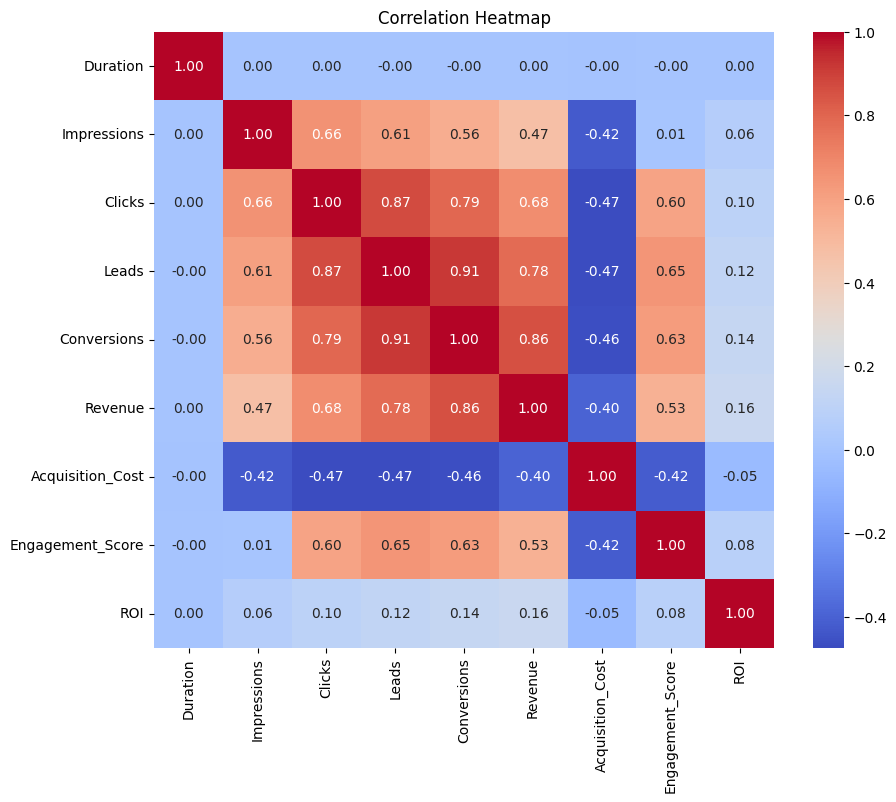

In [20]:
# 6. Correlation heatmap
numeric_cols = ['Duration', 'Impressions', 'Clicks', 'Leads',
                'Conversions', 'Revenue', 'Acquisition_Cost', 'Engagement_Score', 'ROI']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

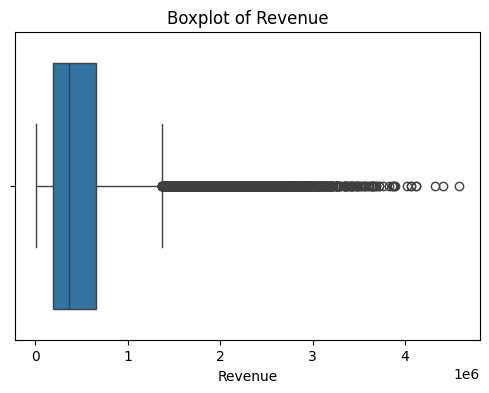

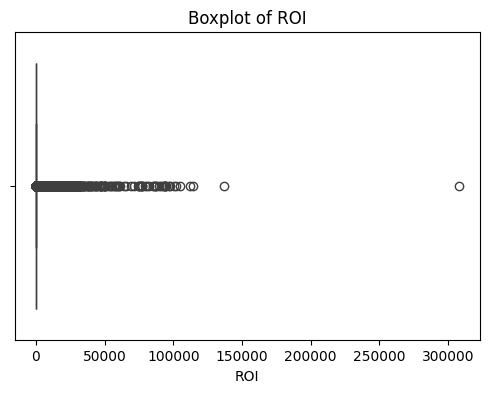

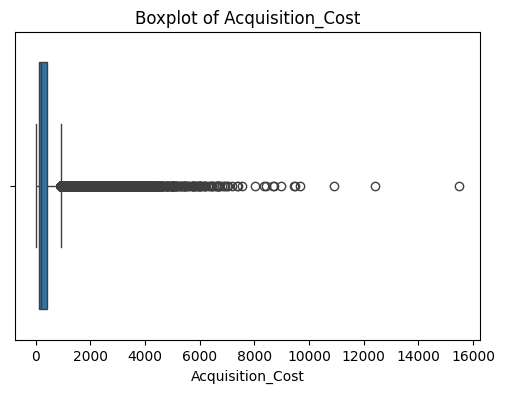

In [21]:
# 7. Boxplots for outlier detection
for col in ['Revenue', 'ROI', 'Acquisition_Cost']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [22]:
# 8. Groupby aggregations - performance by channel/segment
print(df.groupby('Channel_Used')['Revenue'].mean().sort_values(ascending=False))
print()
print(df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False))
print()
print(df.groupby('Customer_Segment')['Conversions'].sum().sort_values(ascending=False))

Channel_Used
YouTube, Google, Email         645406.839695
Email, WhatsApp, Facebook      624476.050725
Google, WhatsApp, YouTube      603478.277778
Facebook, YouTube, Email       595923.050725
Facebook, Instagram, Google    592944.621212
                                   ...      
Email, WhatsApp, Google        436862.351351
YouTube, WhatsApp, Email       436386.557971
WhatsApp, Email, YouTube       423053.892857
WhatsApp, Instagram, Email     417981.082759
Google, Instagram, Facebook    391158.536765
Name: Revenue, Length: 157, dtype: float64

Campaign_Type
Email           364.200929
Social Media    333.197829
Influencer      298.909042
Unknown         292.989230
Paid Ads        285.331499
SEO             256.908561
Name: ROI, dtype: float64

Customer_Segment
College Students         11040504.8
Working Women            11037806.2
Premium Shoppers         10849467.8
Youth                    10775971.4
Tier 2 City Customers    10749777.0
Unknown                   2898259.2
Name: Conver

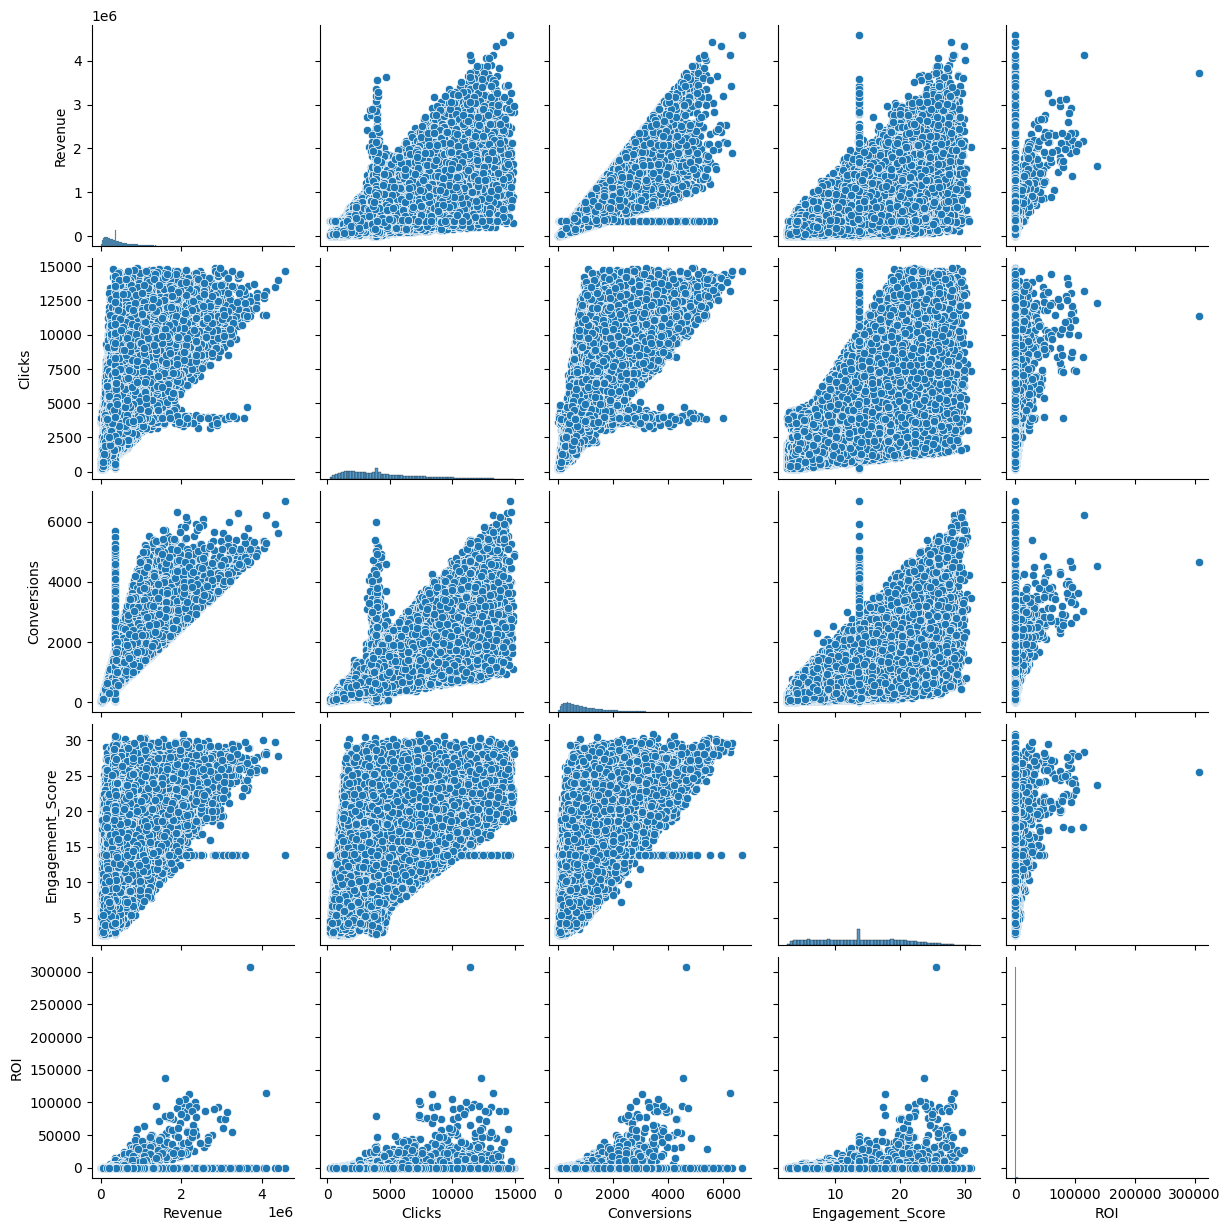

In [23]:
# 1. Pairplot - relationships between key numeric variables
sns.pairplot(df[['Revenue', 'Clicks', 'Conversions', 'Engagement_Score', 'ROI']])
plt.show()

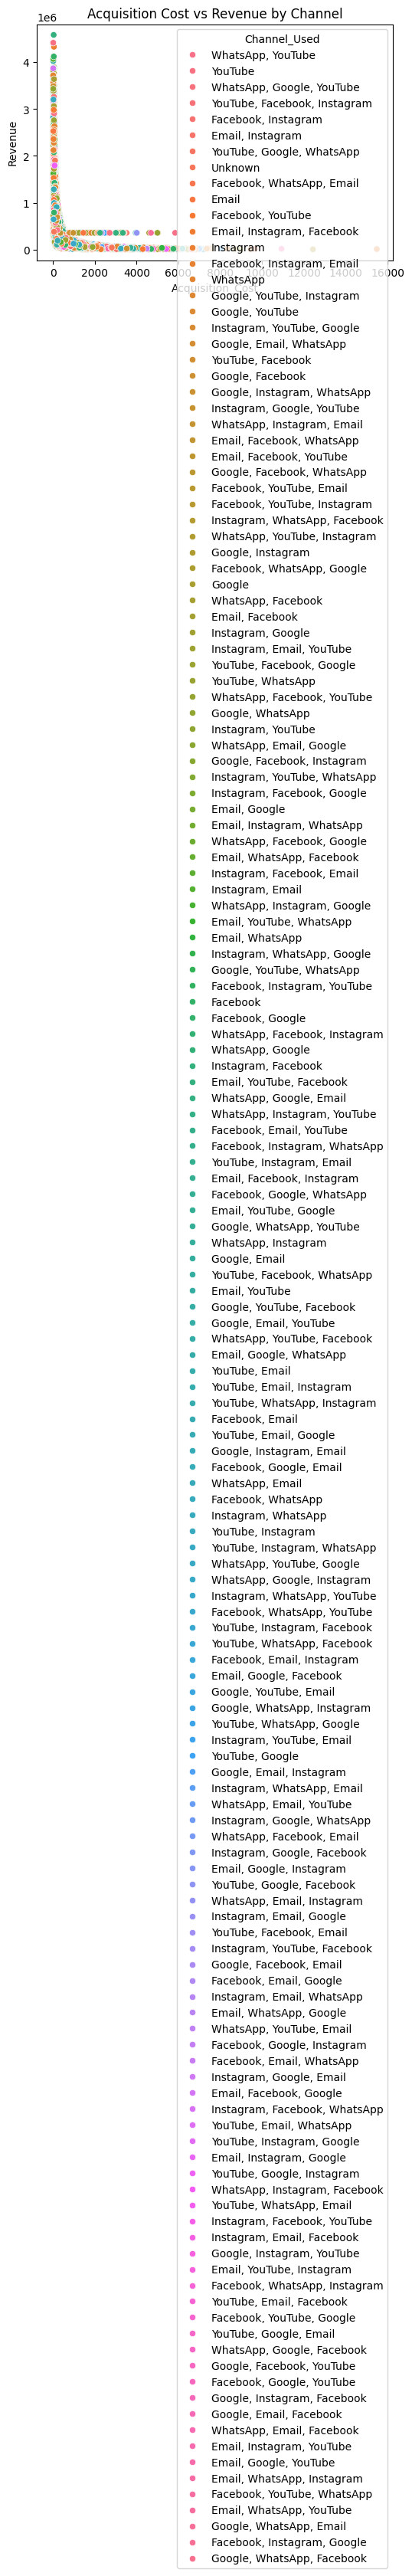

In [24]:
# 2. Scatter plot - Acquisition Cost vs Revenue
plt.figure(figsize=(6,4))
sns.scatterplot(x='Acquisition_Cost', y='Revenue', data=df, hue='Channel_Used')
plt.title('Acquisition Cost vs Revenue by Channel')
plt.show()

In [25]:
# 3. Skewness check for numeric columns
print(df[numeric_cols].skew())

Duration             0.011562
Impressions         -0.006344
Clicks               0.874882
Leads                1.225858
Conversions          1.580391
Revenue              2.122354
Acquisition_Cost     5.375888
Engagement_Score     0.163635
ROI                 29.875403
dtype: float64


In [26]:
# 4. Top/bottom performing campaigns
print("Top 5 by Revenue:")
print(df.nlargest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

print("\nBottom 5 by Revenue:")
print(df.nsmallest(5, 'Revenue')[['Campaign_ID', 'Channel_Used', 'Revenue', 'ROI']])

Top 5 by Revenue:
        Campaign_ID              Channel_Used    Revenue            ROI
12007  NY-CMP-13007  Email, YouTube, Facebook  4579910.0      74.420000
43157  NY-CMP-44157                   YouTube  4412709.0      42.530000
37379  NY-CMP-38379                 Instagram  4326120.0      13.420000
55543  NY-CMP-56543                  Facebook  4119654.0      16.450000
10367  NY-CMP-11367                   YouTube  4119352.0  114077.873165

Bottom 5 by Revenue:
        Campaign_ID                Channel_Used  Revenue       ROI
23406  NY-CMP-24406           Facebook, YouTube   6183.0 -0.970000
26362  NY-CMP-27362  YouTube, Google, Instagram   7476.0 -0.930000
8361    NY-CMP-9361             WhatsApp, Email   7584.0  1.055189
40110  NY-CMP-41110      Google, Email, YouTube   7945.0 -0.960000
38779  NY-CMP-39779                     YouTube   8151.0 -0.840000


In [27]:
# 5. Cross-tabulation - Campaign_Type vs Channel_Used
pd.crosstab(df['Campaign_Type'], df['Channel_Used'])

Channel_Used,Email,"Email, Facebook","Email, Facebook, Google","Email, Facebook, Instagram","Email, Facebook, WhatsApp","Email, Facebook, YouTube","Email, Google","Email, Google, Facebook","Email, Google, Instagram","Email, Google, WhatsApp",...,"YouTube, Instagram","YouTube, Instagram, Email","YouTube, Instagram, Facebook","YouTube, Instagram, Google","YouTube, Instagram, WhatsApp","YouTube, WhatsApp","YouTube, WhatsApp, Email","YouTube, WhatsApp, Facebook","YouTube, WhatsApp, Google","YouTube, WhatsApp, Instagram"
Campaign_Type,,,,,,,,,,,,,,,,,,,,,
Email,540,119,32,20,29,22,106,20,18,27,...,122,21,31,25,24,102,32,13,32,23
Influencer,553,112,21,37,30,29,106,28,30,21,...,127,44,21,27,26,109,33,20,31,21
Paid Ads,590,132,30,30,25,27,109,32,21,30,...,118,25,31,32,27,86,23,38,27,20
SEO,522,112,28,32,25,27,117,25,35,27,...,83,26,25,31,37,129,24,21,29,23
Social Media,551,115,36,26,33,23,106,27,24,34,...,124,27,34,26,27,129,20,23,28,27
Unknown,150,38,7,6,11,8,28,5,8,7,...,37,11,6,7,12,29,6,9,7,6


count    55555.000000
mean         0.222098
std          0.099182
min          0.007993
25%          0.151791
50%          0.204904
75%          0.279262
max          1.531920
Name: Conversion_Rate, dtype: float64


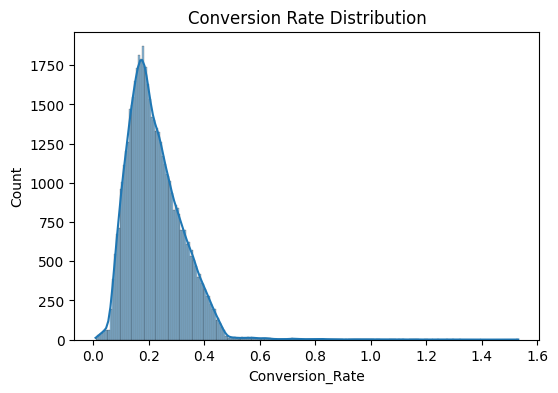

In [28]:
# 6. Conversion rate calculation (derived metric)
df['Conversion_Rate'] = df['Conversions'] / df['Clicks']
print(df['Conversion_Rate'].describe())

plt.figure(figsize=(6,4))
sns.histplot(df['Conversion_Rate'], kde=True)
plt.title('Conversion Rate Distribution')
plt.show()

In [29]:
# 7. Average metrics by Target Audience
df.groupby('Target_Audience')[['Revenue', 'ROI', 'Engagement_Score']].mean().sort_values('Revenue', ascending=False)

,Revenue,ROI,Engagement_Score
Target_Audience,,,
Unknown,517714.329953,305.630052,13.882847
College Students,512579.028485,266.827158,13.864726
Premium Shoppers,511625.691910,316.311091,13.804811
Tier 2 City Customers,505118.065752,333.081495,13.726957
Working Women,504495.886672,346.949477,13.813977
Youth,502442.343511,271.007897,13.668474


In [30]:
# 8. Check for any remaining anomalies after imputation
print("Remaining nulls:")
print(df.isnull().sum().sum())

print("\nNegative values check (shouldn't exist):")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

Remaining nulls:
0

Negative values check (shouldn't exist):
ROI: 12526 negative values


In [31]:
df.to_csv('nykaa_cleaned.csv', index=False)